# 📊 Day 19 — EDA on House Prices Dataset
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ About the Dataset  
2️⃣ Loading & First Look  
3️⃣ Understanding the Data  
4️⃣ Missing Values Analysis  
5️⃣ Target Variable Analysis  
6️⃣ Univariate Analysis  
7️⃣ Bivariate Analysis  
8️⃣ Categorical Analysis  
9️⃣ Correlation Analysis  
🔟 Key Insights & Summary  

---
## 1️⃣ About the Dataset

The House Prices dataset is one of the most popular datasets in data science.

It contains **79 features** describing residential homes in Ames, Iowa.

| Detail | Info |
|--------|------|
| Source | Kaggle — House Prices: Advanced Regression Techniques |
| Rows | 1460 houses |
| Columns | 81 (79 features + Id + SalePrice) |
| Target | SalePrice — final sale price of the house |
| Task | Regression — predict house sale price |

> **Goal of today:** Understand the data deeply before building any model.

---
## 2️⃣ Loading & First Look

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# First 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Last 5 rows
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
# Random sample of 5 rows
df.sample(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
857,858,60,RL,65.0,8125,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,174000
613,614,20,RL,70.0,8402,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2007,New,Partial,147000
1032,1033,60,RL,NaN,14541,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Abnorml,310000
171,172,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
203,204,120,RM,NaN,4438,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,149000


---
## 3️⃣ Understanding the Data

In [6]:
# Shape of dataset
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1460
Columns: 81


In [7]:
# Data types
print("Numerical columns:", df.select_dtypes(include='number').shape[1])
print("Categorical columns:", df.select_dtypes(include='object').shape[1])

Numerical columns: 38
Categorical columns: 43


In [8]:
# Statistical summary of numerical columns
df.describe().T.sort_values('std', ascending=False).head(15)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.195890,79442.502883,34900.0,129975.00,163000.0,214000.00,755000.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
MiscVal,1460.0,43.489041,496.123024,0.0,0.00,0.0,0.00,15500.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
2ndFlrSF,1460.0,346.992466,436.528436,0.0,0.00,0.0,728.00,2065.0
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0


In [9]:
# Statistical summary of categorical columns
df.describe(include='object').T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


---
## 4️⃣ Missing Values Analysis

In [10]:
# Missing values count and percentage
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df)) * 100
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


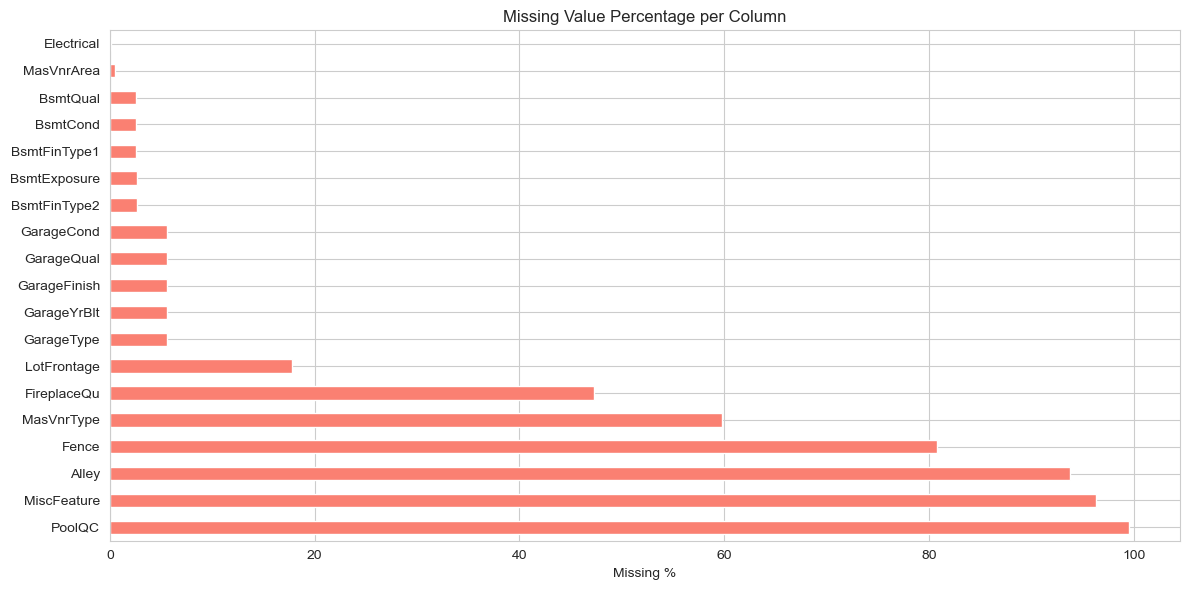

In [11]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing['Missing %'].plot(kind='barh', color='salmon')
plt.title("Missing Value Percentage per Column")
plt.xlabel("Missing %")
plt.tight_layout()
plt.show()

In [12]:
# Columns with more than 50% missing — candidates for dropping
high_missing = missing[missing['Missing %'] > 50]
print("Columns with >50% missing values:")
print(high_missing.index.tolist())

Columns with >50% missing values:
['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


---
## 5️⃣ Target Variable Analysis

Always analyze the target variable first — it determines everything about your modeling approach.

In [13]:
# Basic stats of SalePrice
print("SalePrice Statistics:")
print(df['SalePrice'].describe())

SalePrice Statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


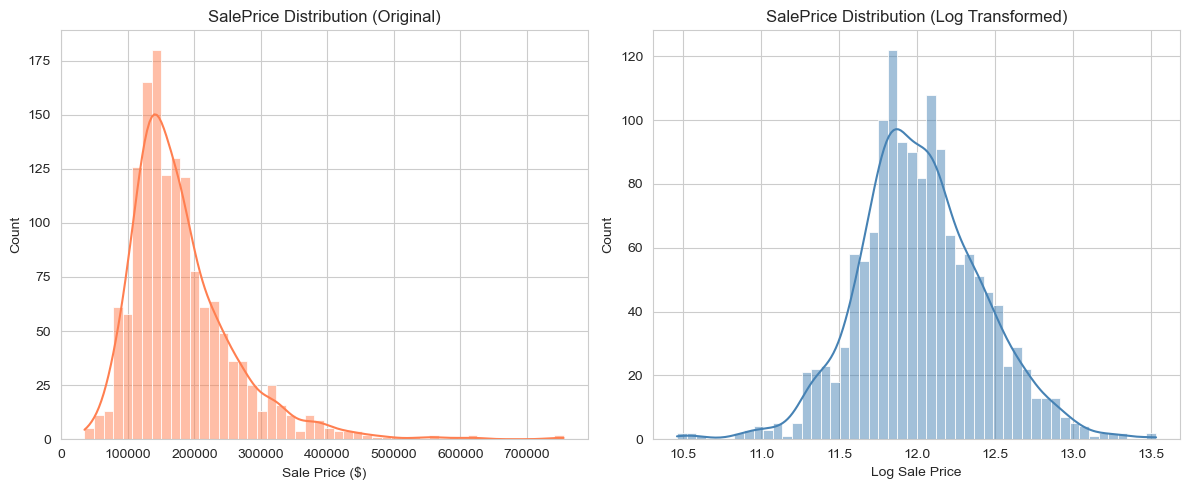

In [14]:
# Distribution of SalePrice
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, color='coral', bins=50)
plt.title("SalePrice Distribution (Original)")
plt.xlabel("Sale Price ($)")

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), kde=True, color='steelblue', bins=50)
plt.title("SalePrice Distribution (Log Transformed)")
plt.xlabel("Log Sale Price")

plt.tight_layout()
plt.show()

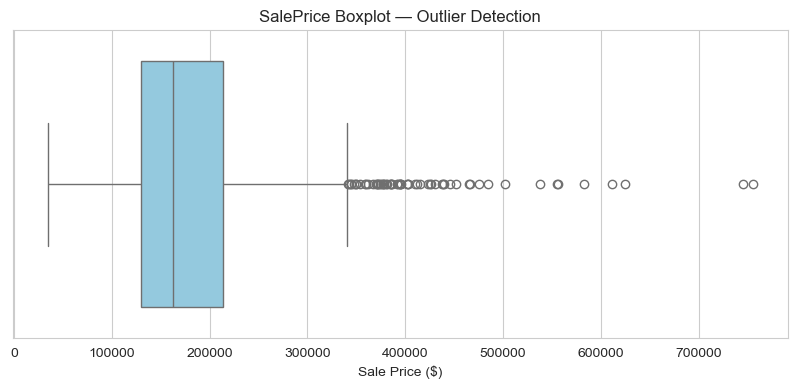

In [15]:
# Boxplot of SalePrice — detect outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['SalePrice'], color='skyblue')
plt.title("SalePrice Boxplot — Outlier Detection")
plt.xlabel("Sale Price ($)")
plt.show()

---
## 6️⃣ Univariate Analysis

Analyzing the most important individual features.

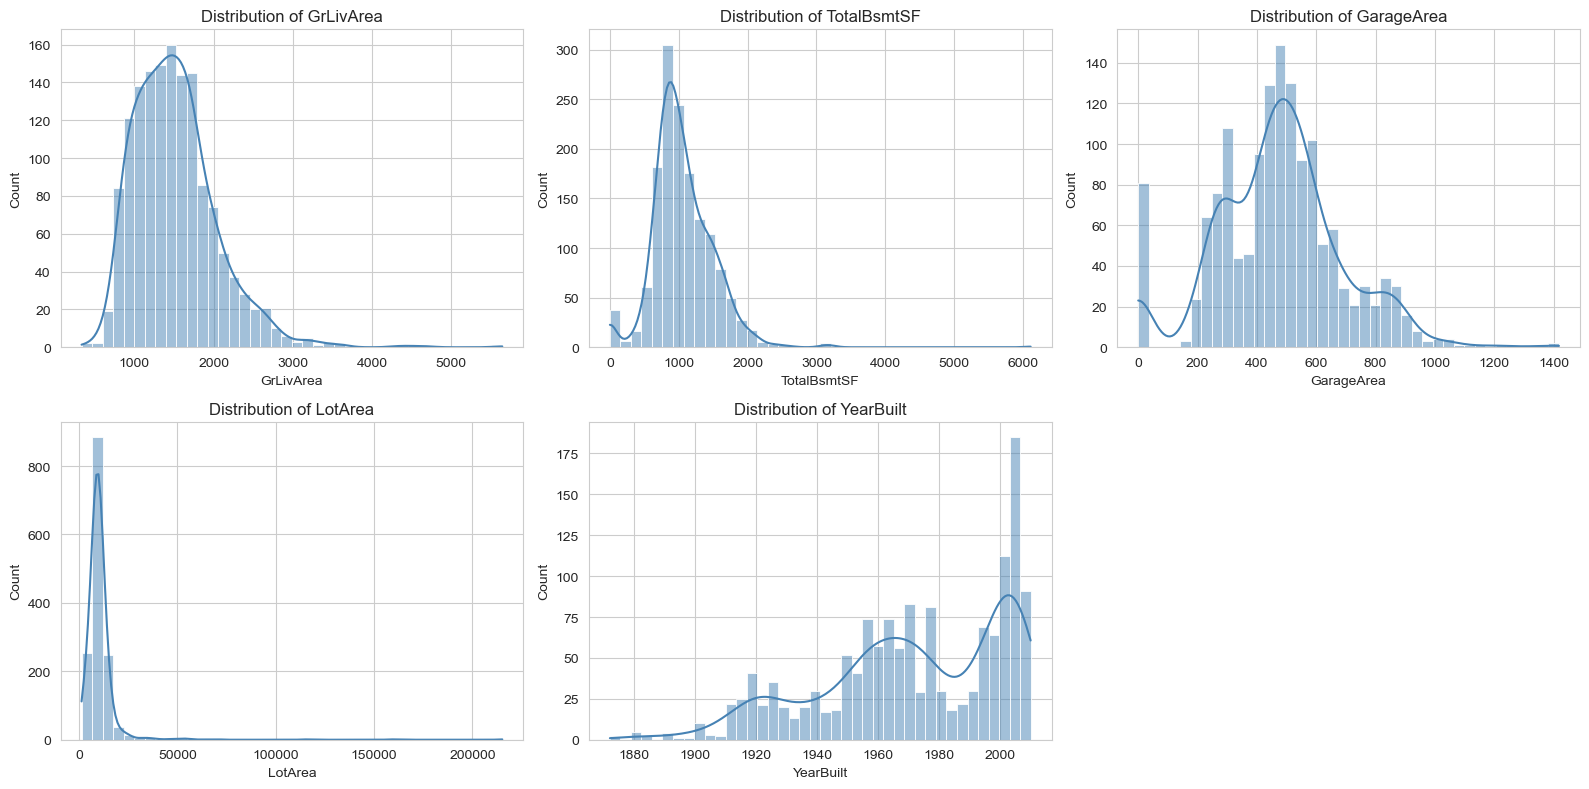

In [16]:
# Distribution of key numerical features
num_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'LotArea', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

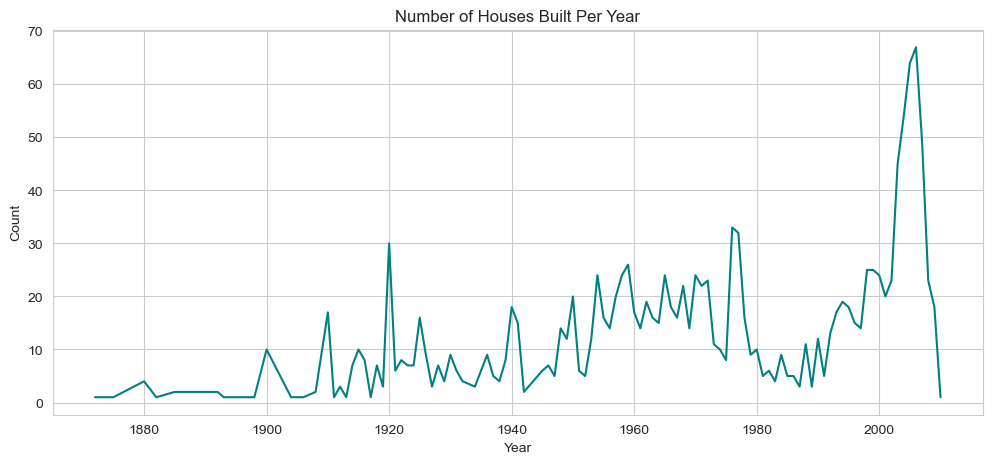

In [17]:
# Year Built distribution
plt.figure(figsize=(12, 5))
df['YearBuilt'].value_counts().sort_index().plot(kind='line', color='teal')
plt.title("Number of Houses Built Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

---
## 7️⃣ Bivariate Analysis

Analyzing how individual features relate to SalePrice.

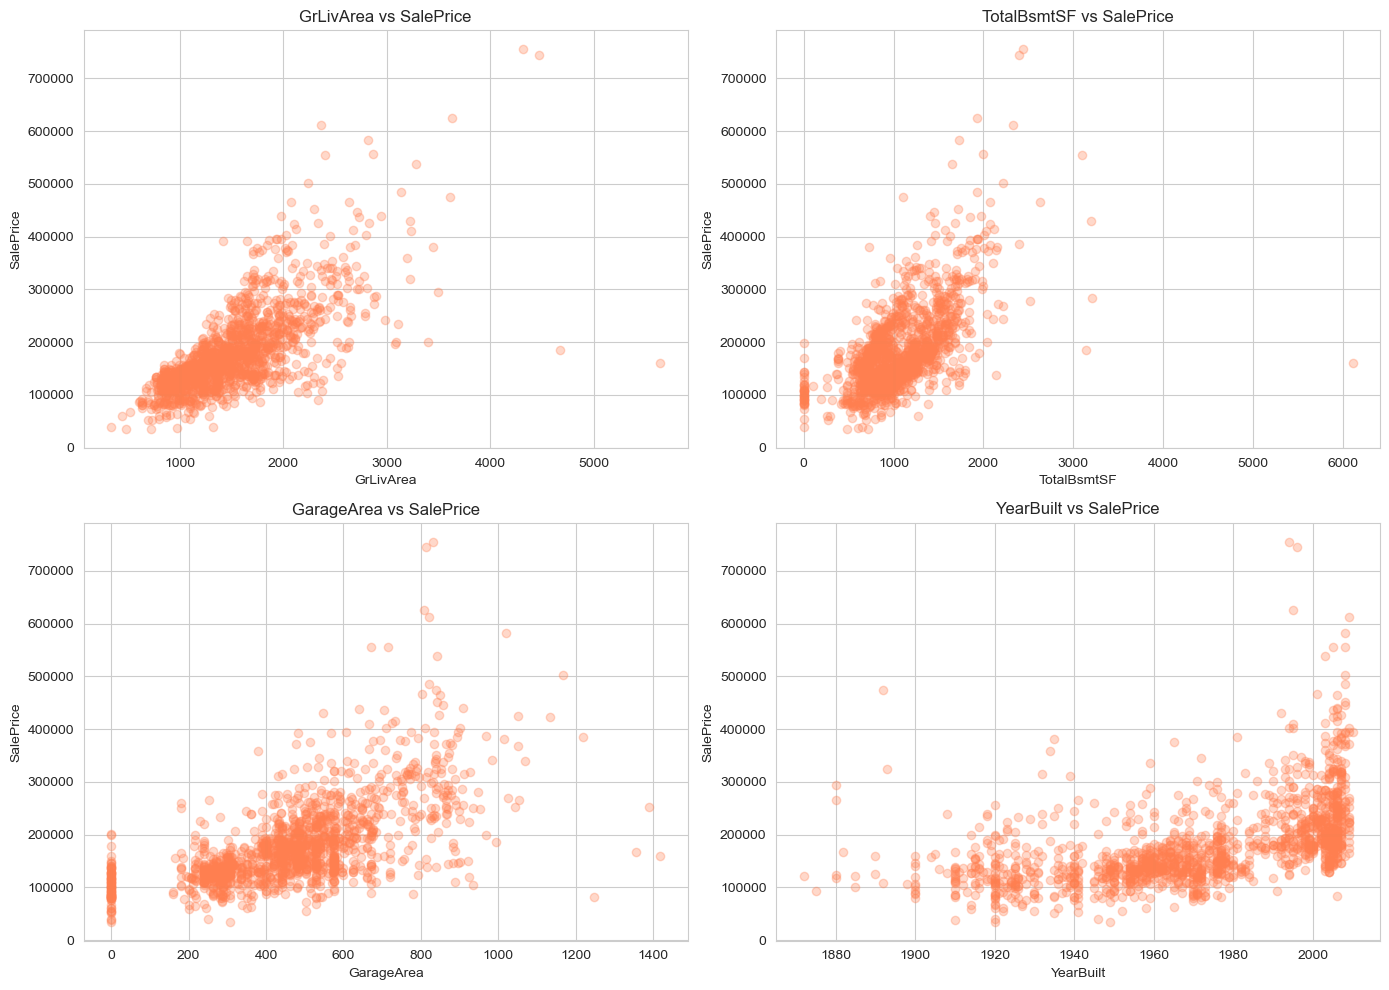

In [18]:
# Scatter plots — key features vs SalePrice
scatter_features = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', 'YearBuilt']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(scatter_features):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.3, color='coral')
    axes[i].set_title(f"{col} vs SalePrice")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("SalePrice")

plt.tight_layout()
plt.show()

C:\Users\aslam\AppData\Local\Temp\ipykernel_9892\762669955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='RdYlGn')


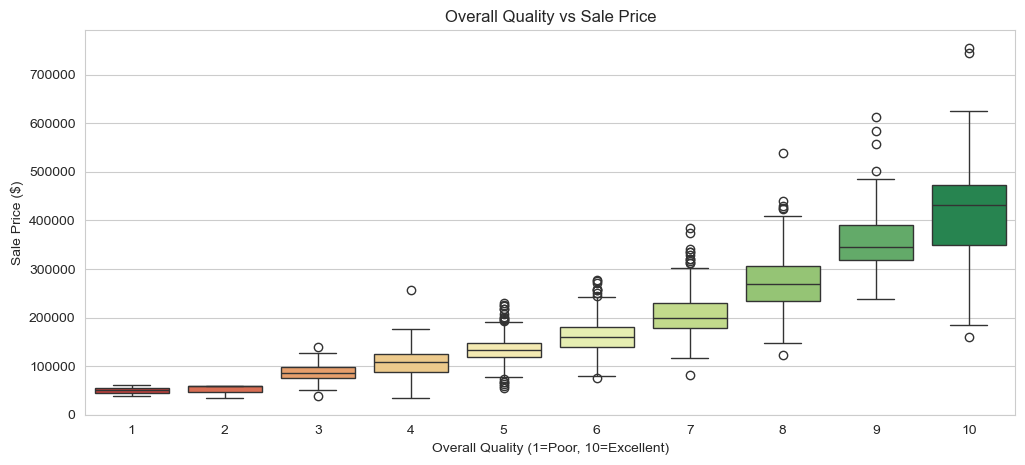

In [19]:
# Overall Quality vs SalePrice
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='RdYlGn')
plt.title("Overall Quality vs Sale Price")
plt.xlabel("Overall Quality (1=Poor, 10=Excellent)")
plt.ylabel("Sale Price ($)")
plt.show()

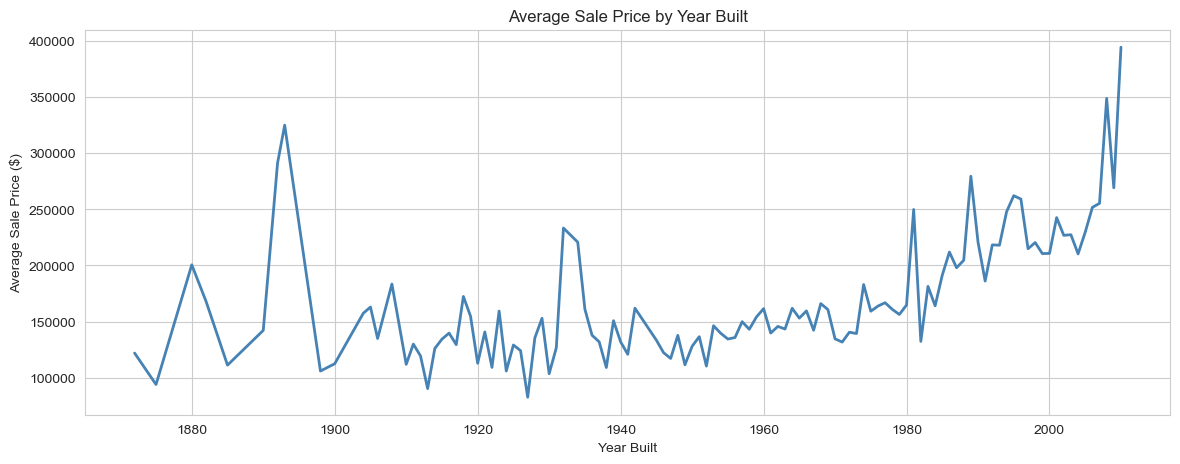

In [20]:
# Year Built vs Average SalePrice
year_price = df.groupby('YearBuilt')['SalePrice'].mean()

plt.figure(figsize=(14, 5))
year_price.plot(kind='line', color='steelblue', linewidth=2)
plt.title("Average Sale Price by Year Built")
plt.xlabel("Year Built")
plt.ylabel("Average Sale Price ($)")
plt.show()

---
## 8️⃣ Categorical Analysis

Analyzing how categorical features affect SalePrice.

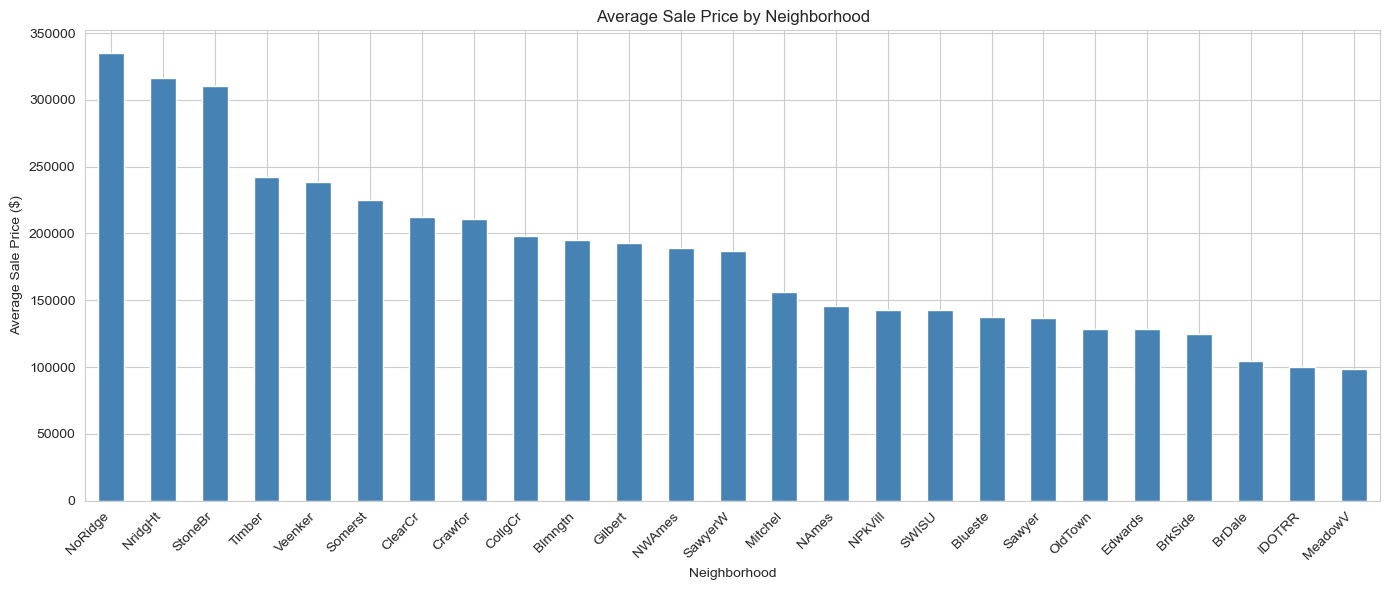

In [21]:
# Neighborhood vs Average SalePrice
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
neighborhood_price.plot(kind='bar', color='steelblue')
plt.title("Average Sale Price by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("Average Sale Price ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\aslam\AppData\Local\Temp\ipykernel_9892\351127169.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='HouseStyle', y='SalePrice', palette='Set2')


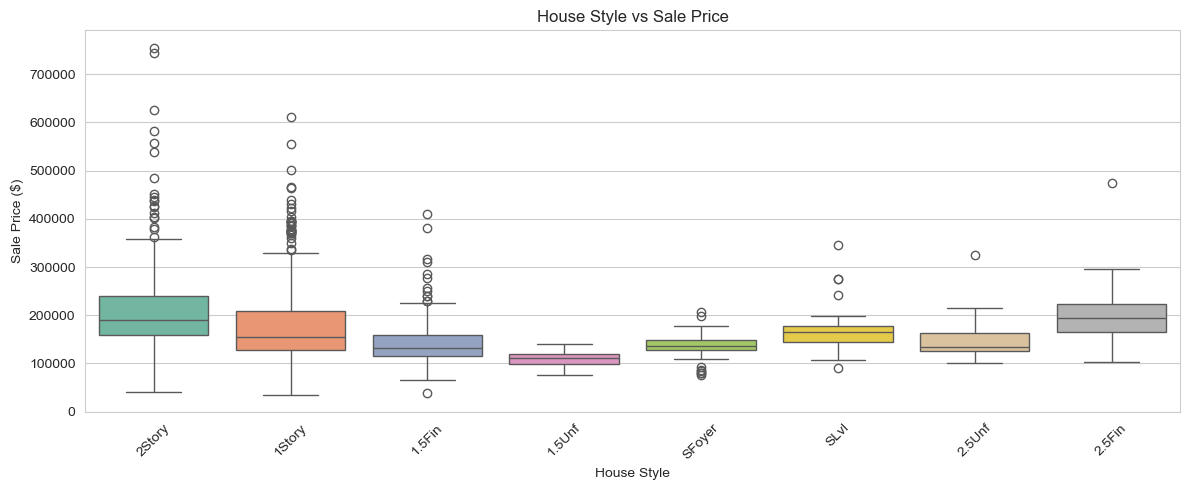

In [22]:
# House Style vs SalePrice
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='HouseStyle', y='SalePrice', palette='Set2')
plt.title("House Style vs Sale Price")
plt.xlabel("House Style")
plt.ylabel("Sale Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

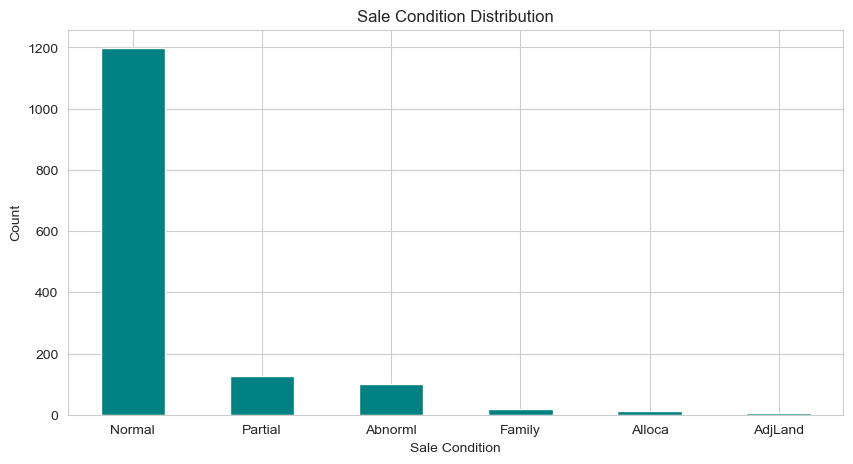

In [23]:
# Sale Condition distribution
plt.figure(figsize=(10, 5))
df['SaleCondition'].value_counts().plot(kind='bar', color='teal')
plt.title("Sale Condition Distribution")
plt.xlabel("Sale Condition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

---
## 9️⃣ Correlation Analysis

Finding which features are most strongly correlated with SalePrice.

In [24]:
# Top 10 features most correlated with SalePrice
corr_matrix = df.select_dtypes(include='number').corr()
top_corr = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)

print("Top 10 Features Correlated with SalePrice:")
top_corr

Top 10 Features Correlated with SalePrice:


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

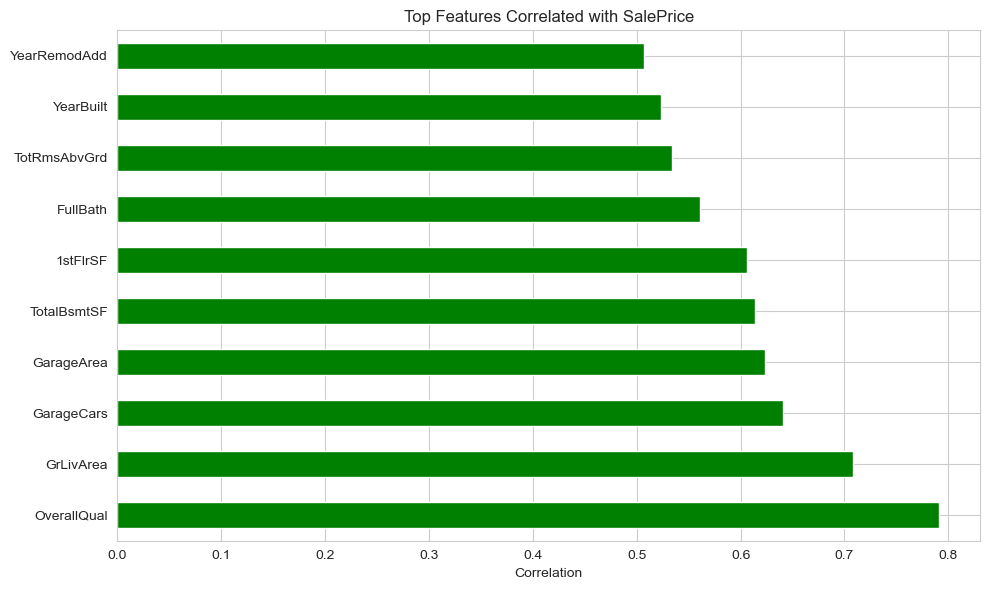

In [25]:
# Visualize top correlations
plt.figure(figsize=(10, 6))
top_corr.drop('SalePrice').plot(kind='barh', color=['green' if x > 0 else 'red' for x in top_corr.drop('SalePrice')])
plt.title("Top Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

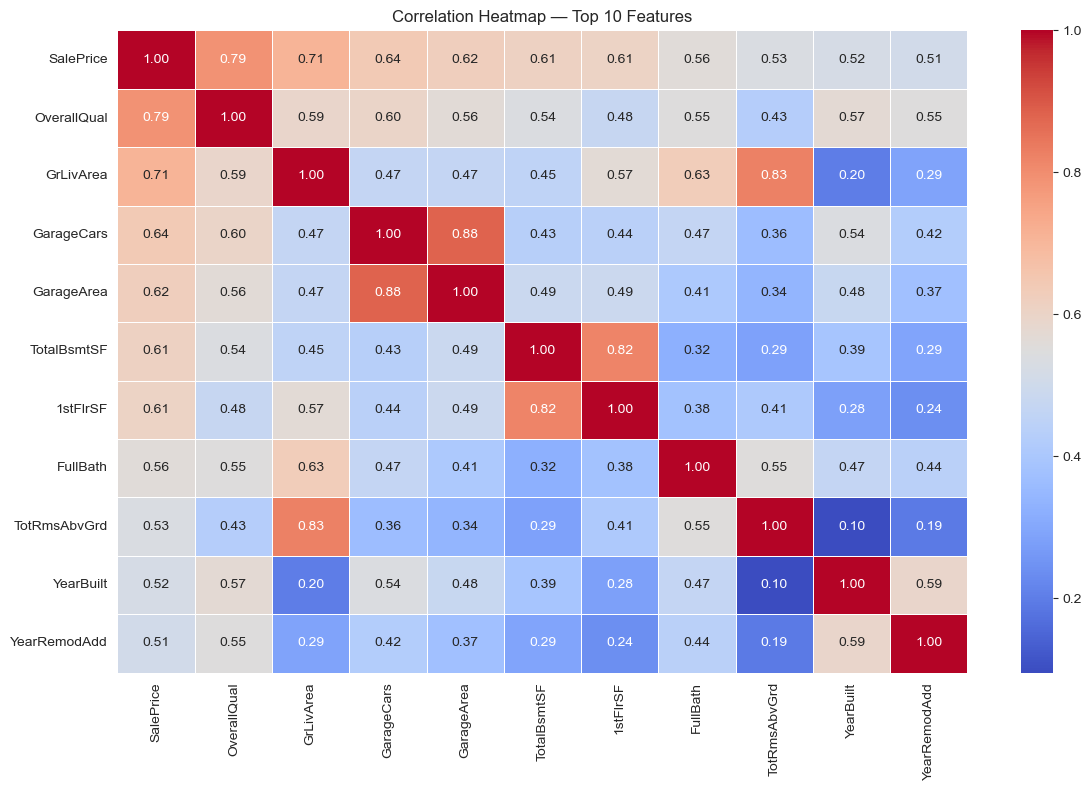

In [26]:
# Heatmap of top 10 features
top_features = top_corr.index.tolist()

plt.figure(figsize=(12, 8))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap — Top 10 Features")
plt.tight_layout()
plt.show()

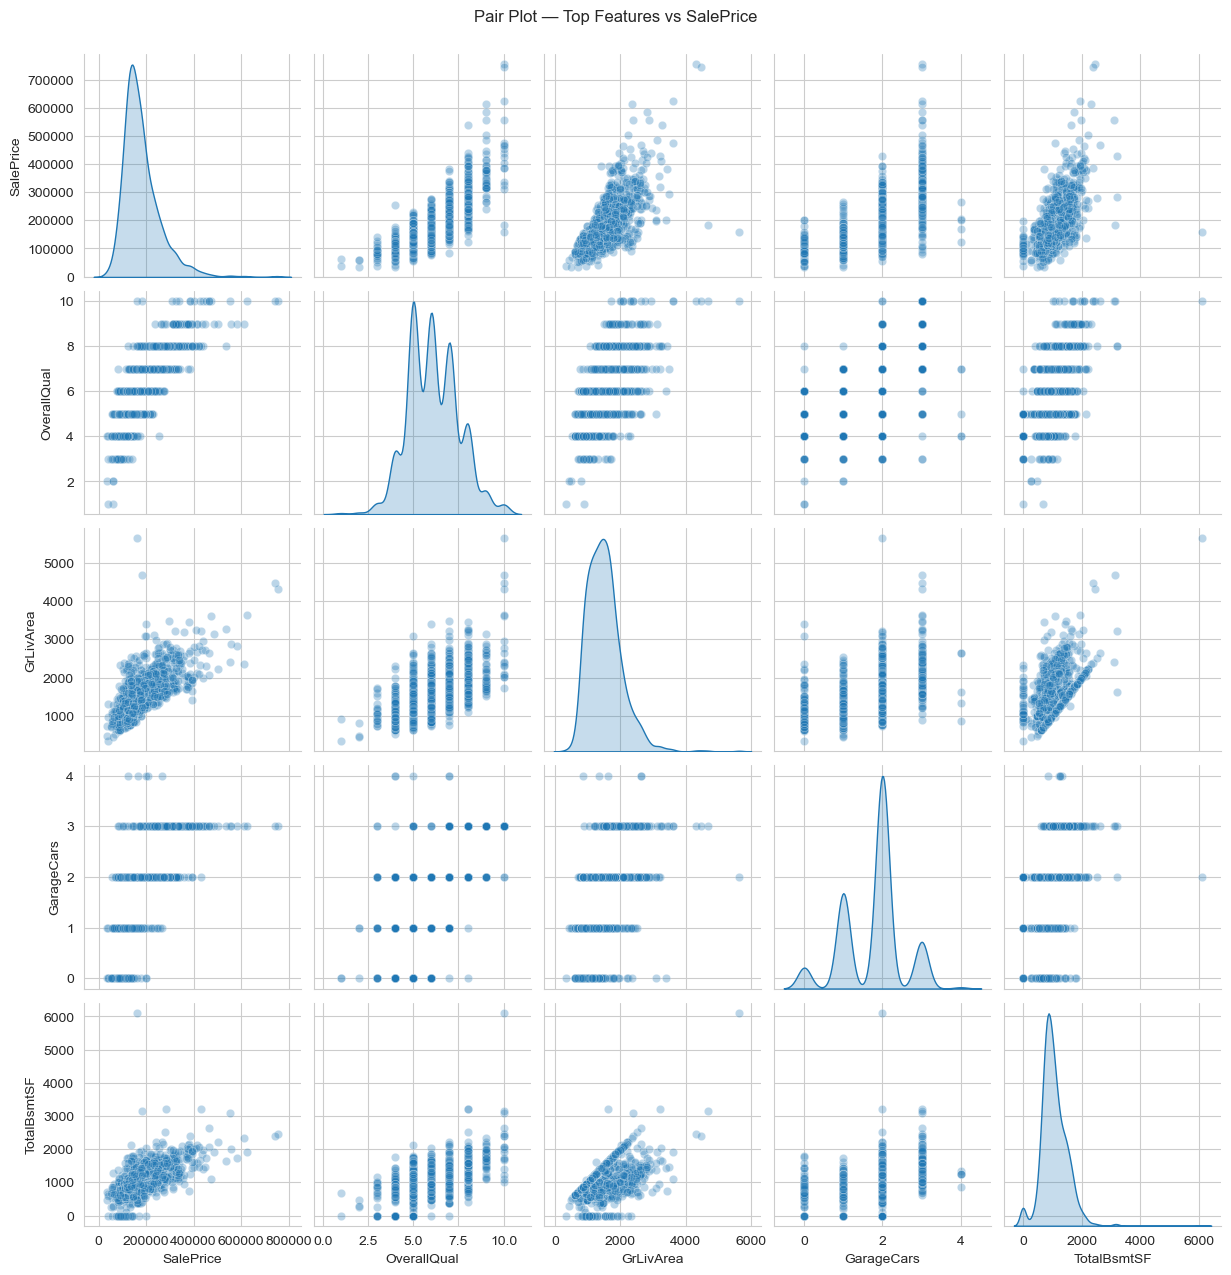

In [27]:
# Pair plot of top 4 features vs SalePrice
top4 = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF']
sns.pairplot(df[top4].dropna(), diag_kind='kde', plot_kws={'alpha': 0.3})
plt.suptitle("Pair Plot — Top Features vs SalePrice", y=1.02)
plt.show()

---
## 🔟 Key Insights & Summary

| # | Insight |
|---|--------|
| 1 | SalePrice is right-skewed — log transformation needed before modeling |
| 2 | OverallQual has the strongest correlation with SalePrice (0.79) |
| 3 | GrLivArea (above ground living area) is the most impactful size feature |
| 4 | Newer houses sell for significantly more than older ones |
| 5 | Neighborhood is a powerful predictor — location matters most |
| 6 | Several columns have >50% missing values and should be dropped |
| 7 | GarageArea, TotalBsmtSF, and YearBuilt are all strongly correlated with price |
| 8 | Houses with higher overall quality show almost no price overlap with lower quality |

---
## 🔑 Key Takeaways

→ Always start EDA by understanding shape, dtypes, and missing values  
→ The target variable should be analyzed first — skewed targets need transformation  
→ OverallQual is the single most important feature in this dataset  
→ Location (Neighborhood) is one of the strongest predictors of house price  
→ Correlation heatmap instantly shows which features to prioritize  
→ Pairplot gives a full picture of relationships between top features  
→ EDA saves you from building a model on wrong assumptions

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 19 of 100 — Keep Learning, Keep Building 🚀*